In [38]:
from google.colab import drive
drive.mount('/content/drive')

# -------------------- Hyperparameters --------------------
SEED = 42

DATA_PATH = '/content/drive/MyDrive/BTC/final.csv'
MODEL_SAVE_PATH = 'encoder_only_transformer_best.pt'

WINDOW_SIZE = 240
TRAIN_STRIDE = 10
BATCH_SIZE = 64
NUM_EPOCHS = 60
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 5e-4
HEAD_HIDDEN_DIM = 32
ENTROPY_REG_WEIGHT = 0.85 # High entropy regularization strength.

D_MODEL = 64
NHEAD = 8
NUM_LAYERS = 1
DIM_FEEDFORWARD = 128
DROPOUT = 0.3
CLASS_NAMES = ['up', 'flat', 'down']
TARGET_COLS = [f'p_{name}' for name in CLASS_NAMES]
OUTPUT_DIM = len(TARGET_COLS)

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

PATIENCE = 25
USE_PROB_FEATURES = False  # Target probability columns are excluded from the feature set.

# -------------------- Seed / Determinism --------------------
import os
import random
import numpy as np
import torch


def set_seed(seed: int = 42) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print(f'Warning: deterministic algorithms could not be fully enabled: {e}')


set_seed(SEED)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
from pathlib import Path
import math
import copy

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, mean_absolute_error, mean_squared_error

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


In [40]:
# 1) Data load
data_path = Path(DATA_PATH)
if not data_path.exists():
    raise FileNotFoundError(f'Missing data file: {data_path}')

df = pd.read_csv(data_path)
required_cols = ['Date', 'close'] + TARGET_COLS
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f'Missing required columns: {missing}')

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date']).reset_index(drop=True)

score_cols = TARGET_COLS.copy()
# finalPreProcess.py defines the 3-class soft probabilities directly for row t.
valid_mask = df[score_cols].notna().all(axis=1)
df = df[valid_mask].reset_index(drop=True)

# Use the soft distribution directly as training target (no clip/no renormalization).
y_soft_df = df[score_cols].copy()
prob_sums = y_soft_df.sum(axis=1)
if not np.allclose(prob_sums.to_numpy(dtype=np.float64), 1.0, atol=1e-6):
    raise ValueError('Target probabilities must sum to 1 for each row.')

exclude_cols = ['Date'] + score_cols
deprecated_feature_cols = ['long_short_ratio']
removed_feature_cols = [c for c in deprecated_feature_cols if c in df.columns]
if removed_feature_cols:
    print('Dropping deprecated feature columns:', removed_feature_cols)
feature_candidates = [c for c in df.columns if c not in exclude_cols and c not in deprecated_feature_cols]
X_df = df[feature_candidates].select_dtypes(include=[np.number]).copy()

X_df = X_df.replace([np.inf, -np.inf], np.nan)
valid_rows = ~X_df.isna().any(axis=1) & ~y_soft_df.isna().any(axis=1)
if not valid_rows.all():
    print('Dropping rows with NaN/inf in features/target:', int((~valid_rows).sum()))

df = df.loc[valid_rows].reset_index(drop=True)
X_df = X_df.loc[valid_rows].reset_index(drop=True)
y_soft_df = y_soft_df.loc[valid_rows].reset_index(drop=True)

print('Rows:', len(df))
print('Num features:', X_df.shape[1])
print(f'Target: {OUTPUT_DIM}-class soft distribution {TARGET_COLS} (used as-is from final.csv)')
print('Average target probabilities:', y_soft_df.mean().round(4).to_dict())
print('Feature columns sample:', X_df.columns[:10].tolist())


Rows: 100674
Num features: 29
Target: 3-class soft distribution ['p_up', 'p_flat', 'p_down'] (used as-is from final.csv)
Average target probabilities: {'p_up': 0.3273, 'p_flat': 0.3469, 'p_down': 0.3258}
Feature columns sample: ['open', 'high', 'low', 'close', 'volume', 'quote_volume', 'count', 'taker_buy_volume', 'taker_buy_quote_volume', 'funding_rate_8h']


In [41]:
# 2) Chronological split
n = len(df)
train_end = int(n * TRAIN_RATIO)
val_end = train_end + int(n * VAL_RATIO)

train_slice = slice(0, train_end)
val_slice = slice(train_end, val_end)
test_slice = slice(val_end, n)

train_X_raw = X_df.iloc[train_slice].copy()
val_X_raw = X_df.iloc[val_slice].copy()
test_X_raw = X_df.iloc[test_slice].copy()

train_y_soft = y_soft_df.iloc[train_slice].copy()
val_y_soft = y_soft_df.iloc[val_slice].copy()
test_y_soft = y_soft_df.iloc[test_slice].copy()

train_dates = df.iloc[train_slice]['Date'].reset_index(drop=True)
val_dates = df.iloc[val_slice]['Date'].reset_index(drop=True)
test_dates = df.iloc[test_slice]['Date'].reset_index(drop=True)

print('Train/Val/Test rows:', len(train_X_raw), len(val_X_raw), len(test_X_raw))


Train/Val/Test rows: 80539 10067 10068


In [42]:
# 3) Hybrid normalization (chronological, train-fit where needed)
ROLLING_WINDOW = 48 * 60


def resolve_feature_columns(column_names, available_columns):
    available_map = {c.lower(): c for c in available_columns}
    resolved = []
    missing = []

    for column_name in column_names:
        resolved_name = available_map.get(column_name.lower())
        if resolved_name is None:
            missing.append(column_name)
        else:
            resolved.append(resolved_name)

    if missing:
        raise KeyError(f'Missing expected feature columns: {missing}')

    return resolved


def resolve_optional_feature_columns(column_names, available_columns):
    available_map = {c.lower(): c for c in available_columns}
    return [available_map[column_name.lower()] for column_name in column_names if column_name.lower() in available_map]


def dedupe_preserve_order(column_names):
    return list(dict.fromkeys(column_names))


price_cols = resolve_feature_columns(
    ['close', 'open', 'high', 'low', 'CME_close', 'CME_open', 'CME_high', 'CME_low'],
    X_df.columns,
)
base_rolling_mean_cols = resolve_feature_columns(
    [
        'volume', 'quote_volume', 'count', 'taker_buy_volume', 'taker_buy_quote_volume',
        'CME_Volume', 'oi_open', 'oi_high', 'oi_low', 'oi_close',
    ],
    X_df.columns,
)
volatility_level_cols = resolve_optional_feature_columns(['atr_14'], X_df.columns)
macro_level_cols = resolve_optional_feature_columns(['fed_net_liquidity'], X_df.columns)
bounded_indicator_cols = resolve_optional_feature_columns(['rsi_14', 'bb_position_20_2', 'fearGreed'], X_df.columns)
atr_relative_cols = resolve_optional_feature_columns(['macd', 'macd_signal', 'macd_hist'], X_df.columns)

rolling_mean_cols = base_rolling_mean_cols + [
    c for c in (volatility_level_cols + macro_level_cols) if c not in base_rolling_mean_cols
]
log_return_cols = price_cols.copy()
rolling_mean_ratio_cols = rolling_mean_cols.copy()
other_standard_scale_cols = [
    c for c in X_df.columns if c not in set(log_return_cols + rolling_mean_ratio_cols + bounded_indicator_cols + atr_relative_cols)
]
standard_scale_cols = dedupe_preserve_order(
    log_return_cols + rolling_mean_ratio_cols + bounded_indicator_cols + atr_relative_cols + other_standard_scale_cols
)

atr_base_col = volatility_level_cols[0] if volatility_level_cols else None

print('Price columns (log return, then train-fit StandardScaler):', log_return_cols)
print(f'Rolling-mean ratio columns ({ROLLING_WINDOW} bars, past-only, then train-fit StandardScaler):', rolling_mean_ratio_cols)
print('Bounded indicator columns (train-fit StandardScaler):', bounded_indicator_cols)
print(f'ATR-relative columns (divide by {atr_base_col}, then StandardScaler):', atr_relative_cols)
print('Other StandardScaler columns (train-fit):', other_standard_scale_cols)

split_labels = np.array(
    ['train'] * len(train_X_raw) + ['val'] * len(val_X_raw) + ['test'] * len(test_X_raw),
    dtype=object,
)
all_X_raw = pd.concat([train_X_raw, val_X_raw, test_X_raw], axis=0, ignore_index=True)
all_y_soft = pd.concat([train_y_soft, val_y_soft, test_y_soft], axis=0, ignore_index=True)
all_dates = pd.concat([train_dates, val_dates, test_dates], axis=0, ignore_index=True)

X_norm_df = all_X_raw.copy()

# MACD family is in price units; express it relative to current ATR to remove BTC price-level drift.
if atr_base_col is not None and atr_relative_cols:
    atr_base = all_X_raw[atr_base_col].replace(0, np.nan)
    for col in atr_relative_cols:
        X_norm_df[col] = all_X_raw[col] / atr_base

for col in log_return_cols:
    X_norm_df[col] = np.log(X_norm_df[col] / X_norm_df[col].shift(1))

for col in rolling_mean_ratio_cols:
    trailing_mean = X_norm_df[col].shift(1).rolling(window=ROLLING_WINDOW, min_periods=1).mean()
    X_norm_df[col] = X_norm_df[col] / trailing_mean

X_norm_df = X_norm_df.replace([np.inf, -np.inf], np.nan)
valid_rows = ~X_norm_df.isna().any(axis=1) & ~all_y_soft.isna().any(axis=1)
dropped_rows = int((~valid_rows).sum())
if dropped_rows:
    print('Dropping rows after hybrid normalization:', dropped_rows)

X_norm_df = X_norm_df.loc[valid_rows].reset_index(drop=True)
all_y_soft = all_y_soft.loc[valid_rows].reset_index(drop=True)
all_dates = all_dates.loc[valid_rows].reset_index(drop=True)
split_labels = split_labels[valid_rows.to_numpy()]

train_mask = split_labels == 'train'
val_mask = split_labels == 'val'
test_mask = split_labels == 'test'

train_X_df = X_norm_df.loc[train_mask].reset_index(drop=True)
val_X_df = X_norm_df.loc[val_mask].reset_index(drop=True)
test_X_df = X_norm_df.loc[test_mask].reset_index(drop=True)

train_y_soft = all_y_soft.loc[train_mask].reset_index(drop=True)
val_y_soft = all_y_soft.loc[val_mask].reset_index(drop=True)
test_y_soft = all_y_soft.loc[test_mask].reset_index(drop=True)

train_dates = all_dates.loc[train_mask].reset_index(drop=True)
val_dates = all_dates.loc[val_mask].reset_index(drop=True)
test_dates = all_dates.loc[test_mask].reset_index(drop=True)

feature_scaler = StandardScaler()
train_X_df.loc[:, standard_scale_cols] = feature_scaler.fit_transform(train_X_df[standard_scale_cols])
val_X_df.loc[:, standard_scale_cols] = feature_scaler.transform(val_X_df[standard_scale_cols])
test_X_df.loc[:, standard_scale_cols] = feature_scaler.transform(test_X_df[standard_scale_cols])

train_X = train_X_df.to_numpy(dtype=np.float32)
val_X = val_X_df.to_numpy(dtype=np.float32)
test_X = test_X_df.to_numpy(dtype=np.float32)

# Soft labels stay as probability vectors.
train_y = train_y_soft.to_numpy(dtype=np.float32)
val_y = val_y_soft.to_numpy(dtype=np.float32)
test_y = test_y_soft.to_numpy(dtype=np.float32)

for split_name, feature_arr, target_arr in [('train', train_X, train_y), ('val', val_X, val_y), ('test', test_X, test_y)]:
    if len(feature_arr) == 0:
        raise ValueError(f'{split_name} split is empty after hybrid normalization.')
    if target_arr.ndim != 2 or target_arr.shape[1] != OUTPUT_DIM:
        raise ValueError(f'{split_name} targets must have shape [N, {OUTPUT_DIM}], got {target_arr.shape}')

print('Normalized rows (train/val/test):', len(train_X), len(val_X), len(test_X))
print('Normalized X shapes:', train_X.shape, val_X.shape, test_X.shape)
print('Y shapes:', train_y.shape, val_y.shape, test_y.shape)
if len(train_y) > 0:
    print('Example soft target (train[0]):', train_y[0])


Price columns (log return, then train-fit StandardScaler): ['close', 'open', 'high', 'low', 'CME_Close', 'CME_Open', 'CME_High', 'CME_Low']
Rolling-mean ratio columns (2880 bars, past-only, then train-fit StandardScaler): ['volume', 'quote_volume', 'count', 'taker_buy_volume', 'taker_buy_quote_volume', 'CME_Volume', 'oi_open', 'oi_high', 'oi_low', 'oi_close', 'atr_14', 'fed_net_liquidity']
Bounded indicator columns (train-fit StandardScaler): ['rsi_14', 'bb_position_20_2', 'fearGreed']
ATR-relative columns (divide by atr_14, then StandardScaler): ['macd', 'macd_signal', 'macd_hist']
Other StandardScaler columns (train-fit): ['funding_rate_8h', 'long_ratio', 'short_ratio']
Dropping rows after hybrid normalization: 1
Normalized rows (train/val/test): 80538 10067 10068
Normalized X shapes: (80538, 29) (10067, 29) (10068, 29)
Y shapes: (80538, 3) (10067, 3) (10068, 3)
Example soft target (train[0]): [0.05162809 0.20651235 0.74185956]


In [43]:
# 4) Sliding window builder
def build_sliding_windows(X_arr, y_arr, dates, window_size):
    if len(X_arr) < window_size:
        raise ValueError(f'Split has fewer rows than WINDOW_SIZE ({len(X_arr)} < {window_size})')

    X_windows = []
    y_targets = []
    target_dates = []

    # Alignment rule: window [start_idx ... end_idx] predicts y[end_idx] (not y[end_idx + 1]).
    for end_idx in range(window_size - 1, len(X_arr)):
        start_idx = end_idx - window_size + 1
        X_windows.append(X_arr[start_idx:end_idx + 1])
        y_targets.append(y_arr[end_idx])  # target is the last row in the window
        target_dates.append(dates.iloc[end_idx])

    X_windows = np.asarray(X_windows, dtype=np.float32)
    y_targets = np.asarray(y_targets, dtype=np.float32)
    target_dates = pd.Series(target_dates)
    return X_windows, y_targets, target_dates

X_train_win, y_train_win, train_target_dates = build_sliding_windows(train_X, train_y, train_dates, WINDOW_SIZE)
X_val_win, y_val_win, val_target_dates = build_sliding_windows(val_X, val_y, val_dates, WINDOW_SIZE)
X_test_win, y_test_win, test_target_dates = build_sliding_windows(test_X, test_y, test_dates, WINDOW_SIZE)

print('Train windows:', X_train_win.shape, y_train_win.shape)
print('Val windows:', X_val_win.shape, y_val_win.shape)
print('Test windows:', X_test_win.shape, y_test_win.shape)

# Sanity check: first train window uses rows [0..WINDOW_SIZE-1] and predicts row WINDOW_SIZE-1.
if len(y_train_win) > 0:
    np.testing.assert_allclose(y_train_win[0], train_y[WINDOW_SIZE - 1], rtol=0.0, atol=1e-7)
    print(f'Alignment check passed: [0..{WINDOW_SIZE - 1}] window -> target row {WINDOW_SIZE - 1}.')


Train windows: (80299, 240, 29) (80299, 3)
Val windows: (9828, 240, 29) (9828, 3)
Test windows: (9829, 240, 29) (9829, 3)
Alignment check passed: [0..239] window -> target row 239.


In [44]:
# 5) Dataset + DataLoaders
class SlidingWindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class RandomOffsetStrideDataset(Dataset):
    def __init__(self, X, y, stride, seed):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.stride = stride
        self.rng = np.random.default_rng(seed)
        self.windows_per_epoch = max(1, len(self.X) // self.stride)
        self.current_offset = 0
        self.current_indices = torch.arange(len(self.X), dtype=torch.long)
        self.refresh_epoch()

    def refresh_epoch(self):
        max_offset = min(self.stride, len(self.X)) - 1
        self.current_offset = int(self.rng.integers(0, max_offset + 1))
        current_indices = np.arange(self.current_offset, len(self.X), self.stride, dtype=np.int64)
        if len(current_indices) > self.windows_per_epoch:
            current_indices = current_indices[:self.windows_per_epoch]
        self.current_indices = torch.tensor(current_indices, dtype=torch.long)
        return self.current_offset

    def __len__(self):
        return len(self.current_indices)

    def __getitem__(self, idx):
        base_idx = int(self.current_indices[idx])
        return self.X[base_idx], self.y[base_idx]

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

train_ds = RandomOffsetStrideDataset(X_train_win, y_train_win, stride=TRAIN_STRIDE, seed=SEED)
val_ds = SlidingWindowDataset(X_val_win, y_val_win)
test_ds = SlidingWindowDataset(X_test_win, y_test_win)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, worker_init_fn=seed_worker, generator=g, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, worker_init_fn=seed_worker, generator=g, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, worker_init_fn=seed_worker, generator=g, drop_last=False)

print(f'DataLoaders ready. Train stride={TRAIN_STRIDE}, windows per epoch={len(train_ds)}')


DataLoaders ready. Train stride=10, windows per epoch=8029


In [45]:
# 6) Encoder-only Transformer model
class EncoderOnlyTransformer(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers, dim_feedforward, dropout, head_hidden_dim, max_len=4096, output_dim=OUTPUT_DIM):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.token_norm = nn.LayerNorm(d_model)
        self.head_norm = nn.LayerNorm(d_model * 2)
        self.head = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, head_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden_dim, output_dim)
        )

    def forward(self, x):
        # x: [B, T, F]
        _, seq_len, _ = x.shape
        h = self.input_proj(x)
        h = h + self.pos_embedding[:, :seq_len, :]
        h = self.encoder(h)

        # Combine global context (mean pooling) with the most recent token.
        h_mean = self.token_norm(h.mean(dim=1))
        h_last = self.token_norm(h[:, -1, :])
        h_repr = torch.cat([h_mean, h_last], dim=-1)
        h_repr = self.head_norm(h_repr)
        logits = self.head(h_repr)
        return logits  # logits -> log_softmax for KLDivLoss

model = EncoderOnlyTransformer(
    input_dim=X_train_win.shape[-1],
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    head_hidden_dim=HEAD_HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
).to(device)

criterion = nn.KLDivLoss(reduction='batchmean')
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
# OneCycleLR: tek bir cycle icinde linear warmup + cosine decay yapar.
# Restart yoktur; her batch sonrasi step() cagirilmalidir.
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.15,        # ilk %10 warmup, kalan %90 cosine decay
    anneal_strategy='cos',
    div_factor=10.0,      # baslangic LR = max_lr / div_factor
    final_div_factor=1e4, # bitis LR = max_lr / (div_factor * final_div_factor)
)

print(model)
print(f'Loss: KLDivLoss + controlled entropy penalty (lambda={ENTROPY_REG_WEIGHT}) | LR scheduler: OneCycleLR | max_lr={LEARNING_RATE}')


EncoderOnlyTransformer(
  (input_proj): Linear(in_features=29, out_features=64, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (token_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (head_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=T

In [46]:
# 7) Training / validation loops

def entropy_regularized_kl_loss(logits, targets, criterion, entropy_reg_weight):
    log_probs = torch.log_softmax(logits, dim=-1)
    probs = log_probs.exp()
    kl_loss = criterion(log_probs, targets)
    pred_entropy = -(probs * log_probs).sum(dim=-1)
    target_entropy = -(targets * targets.clamp_min(1e-12).log()).sum(dim=-1)
    entropy_penalty = torch.clamp_min(pred_entropy - target_entropy, 0.0).mean()
    total_loss = kl_loss + entropy_reg_weight * entropy_penalty
    return total_loss

def train_one_epoch(model, loader, optimizer, criterion, scheduler, device):
    model.train()
    running_loss = 0.0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = entropy_regularized_kl_loss(logits, yb, criterion, ENTROPY_REG_WEIGHT)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()  # OneCycleLR: step after every batch.

        running_loss += loss.item() * xb.size(0)

    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = entropy_regularized_kl_loss(logits, yb, criterion, ENTROPY_REG_WEIGHT)
        running_loss += loss.item() * xb.size(0)

    return running_loss / len(loader.dataset)


history = {'train_loss': [], 'val_loss': [], 'lr': []}
best_val = float('inf')
best_state = None
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_offset = train_ds.refresh_epoch()
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scheduler, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    # OneCycleLR does not need an epoch-level step call.
    curr_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['lr'].append(curr_lr)

    print(f'Epoch {epoch:03d} | offset={train_offset:02d} | train_windows={len(train_ds)} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | lr={curr_lr:.8f}')

    if val_loss < best_val:
        best_val = val_loss
        best_state = {
            'model_state_dict': copy.deepcopy(model.state_dict()),
            'optimizer_state_dict': copy.deepcopy(optimizer.state_dict()),
            'best_val_loss': best_val,
            'config': {
                'window_size': WINDOW_SIZE,
                'batch_size': BATCH_SIZE,
                'train_stride': TRAIN_STRIDE,
                'd_model': D_MODEL,
                'nhead': NHEAD,
                'num_layers': NUM_LAYERS,
                'dim_feedforward': DIM_FEEDFORWARD,
                'dropout': DROPOUT,
                'head_hidden_dim': HEAD_HIDDEN_DIM,
                'entropy_reg_weight': ENTROPY_REG_WEIGHT,
                'output_dim': OUTPUT_DIM,
                'target_columns': TARGET_COLS,
                'class_names': CLASS_NAMES,
                'feature_columns': X_df.columns.tolist(),
                'price_log_return_cols': price_cols,
                'rolling_mean_cols': rolling_mean_cols,
                'bounded_indicator_cols': bounded_indicator_cols,
                'atr_relative_cols': atr_relative_cols,
                'atr_base_col': atr_base_col,
                'other_standard_scale_cols': other_standard_scale_cols,
                'standard_scale_cols': standard_scale_cols,
                'rolling_window': ROLLING_WINDOW,
            }
        }
        torch.save(best_state, MODEL_SAVE_PATH)
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch}.')
        break

if best_state is None:
    raise RuntimeError('Training did not produce a valid best_state.')

# Ensure evaluation uses the best validation model.
model.load_state_dict(best_state['model_state_dict'])
print('Best model checkpoint path:', MODEL_SAVE_PATH)


Epoch 001 | offset=07 | train_windows=8029 | train_loss=0.490256 | val_loss=0.494261 | lr=0.00006359
Epoch 002 | offset=06 | train_windows=8029 | train_loss=0.490104 | val_loss=0.492992 | lr=0.00010273
Epoch 003 | offset=04 | train_windows=8029 | train_loss=0.487330 | val_loss=0.491097 | lr=0.00016268
Epoch 004 | offset=04 | train_windows=8029 | train_loss=0.483521 | val_loss=0.488191 | lr=0.00023620
Epoch 005 | offset=08 | train_windows=8029 | train_loss=0.483389 | val_loss=0.485414 | lr=0.00031441
Epoch 006 | offset=00 | train_windows=8029 | train_loss=0.475105 | val_loss=0.481845 | lr=0.00038786
Epoch 007 | offset=06 | train_windows=8029 | train_loss=0.476068 | val_loss=0.480964 | lr=0.00044767
Epoch 008 | offset=02 | train_windows=8029 | train_loss=0.469751 | val_loss=0.481107 | lr=0.00048662
Epoch 009 | offset=00 | train_windows=8029 | train_loss=0.469070 | val_loss=0.480757 | lr=0.00050000
Epoch 010 | offset=05 | train_windows=8029 | train_loss=0.471561 | val_loss=0.478702 | lr=0

In [47]:
# 8) Test evaluation (true soft scores vs model probabilities)
model.load_state_dict(best_state['model_state_dict'])
model.eval()

true_prob_list = []
logit_list = []
prob_list = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.softmax(logits, dim=-1)

        true_prob_list.append(yb.numpy())
        logit_list.append(logits.cpu().numpy())
        prob_list.append(probs.cpu().numpy())

y_true_probs = np.concatenate(true_prob_list, axis=0)
y_logits = np.concatenate(logit_list, axis=0)
y_probs = np.concatenate(prob_list, axis=0)

if len(test_target_dates) != len(y_logits):
    raise ValueError(
        f'Length mismatch: test_dates={len(test_target_dates)} vs model_outputs={len(y_logits)}'
    )

test_kl_loss = F.kl_div(
    torch.log(torch.from_numpy(y_probs).clamp_min(1e-12)),
    torch.from_numpy(y_true_probs),
    reduction='batchmean'
).item()
test_mse = mean_squared_error(y_true_probs, y_probs)
test_mae = mean_absolute_error(y_true_probs, y_probs)

results = pd.DataFrame({
    'Date': test_target_dates.dt.strftime('%Y-%m-%d %H:%M:%S').values,
})
for idx, class_name in enumerate(CLASS_NAMES):
    results[f'true_p_{class_name}'] = y_true_probs[:, idx]
    results[f'logit_{class_name}'] = y_logits[:, idx]
    results[f'prob_{class_name}'] = y_probs[:, idx]

print(f'Test windows: {len(results)}')
print(f'Test KL loss (true probs vs model probs): {test_kl_loss:.8f}')
print(f'Test MSE (probs): {test_mse:.8f} | Test MAE (probs): {test_mae:.8f}')
results.head(10)


Test windows: 9829
Test KL loss (true probs vs model probs): 0.30180055
Test MSE (probs): 0.06402060 | Test MAE (probs): 0.21369462


,Date,true_p_up,logit_up,prob_up,true_p_flat,logit_flat,prob_flat,true_p_down,logit_down,prob_down
0,2025-08-07 21:30:00,0.039694,-0.306728,0.208393,0.442738,0.687049,0.562956,0.517568,-0.213954,0.228651
1,2025-08-07 22:00:00,0.077276,-0.174860,0.291874,0.309104,0.162273,0.408893,0.613620,-0.149955,0.299234
2,2025-08-07 22:30:00,0.079299,-0.230517,0.263914,0.317197,0.307036,0.451773,0.603504,-0.156067,0.284313
3,2025-08-07 23:00:00,0.091167,-0.310868,0.207702,0.364666,0.684489,0.561978,0.544167,-0.207506,0.230320
4,2025-08-07 23:30:00,0.070949,-0.308708,0.208456,0.283795,0.681543,0.561144,0.645257,-0.208614,0.230401
5,2025-08-08 00:00:00,0.098980,-0.173690,0.242061,0.395921,0.685829,0.571754,0.505099,-0.436137,0.186185
6,2025-08-08 00:30:00,0.079215,-0.061049,0.355803,0.316860,-0.356551,0.264773,0.603925,0.003229,0.379424
7,2025-08-08 01:00:00,0.104350,-0.199344,0.285653,0.534502,-0.197571,0.286160,0.361148,0.205441,0.428188
8,2025-08-08 01:30:00,0.136039,-0.312747,0.203400,0.608476,0.719996,0.571301,0.255485,-0.210494,0.225299
9,2025-08-08 02:00:00,0.123740,-0.326984,0.200758,0.574478,0.713551,0.568294,0.301782,-0.186894,0.230948


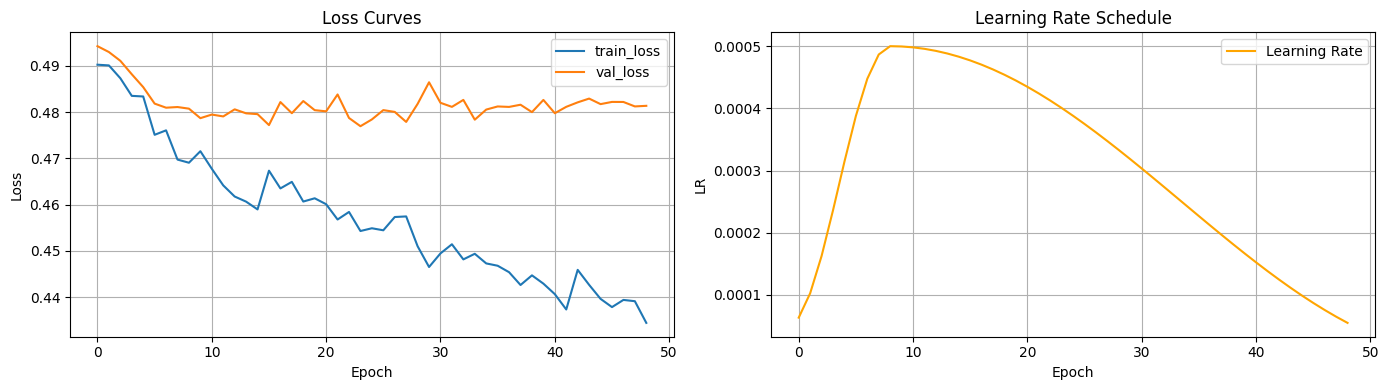

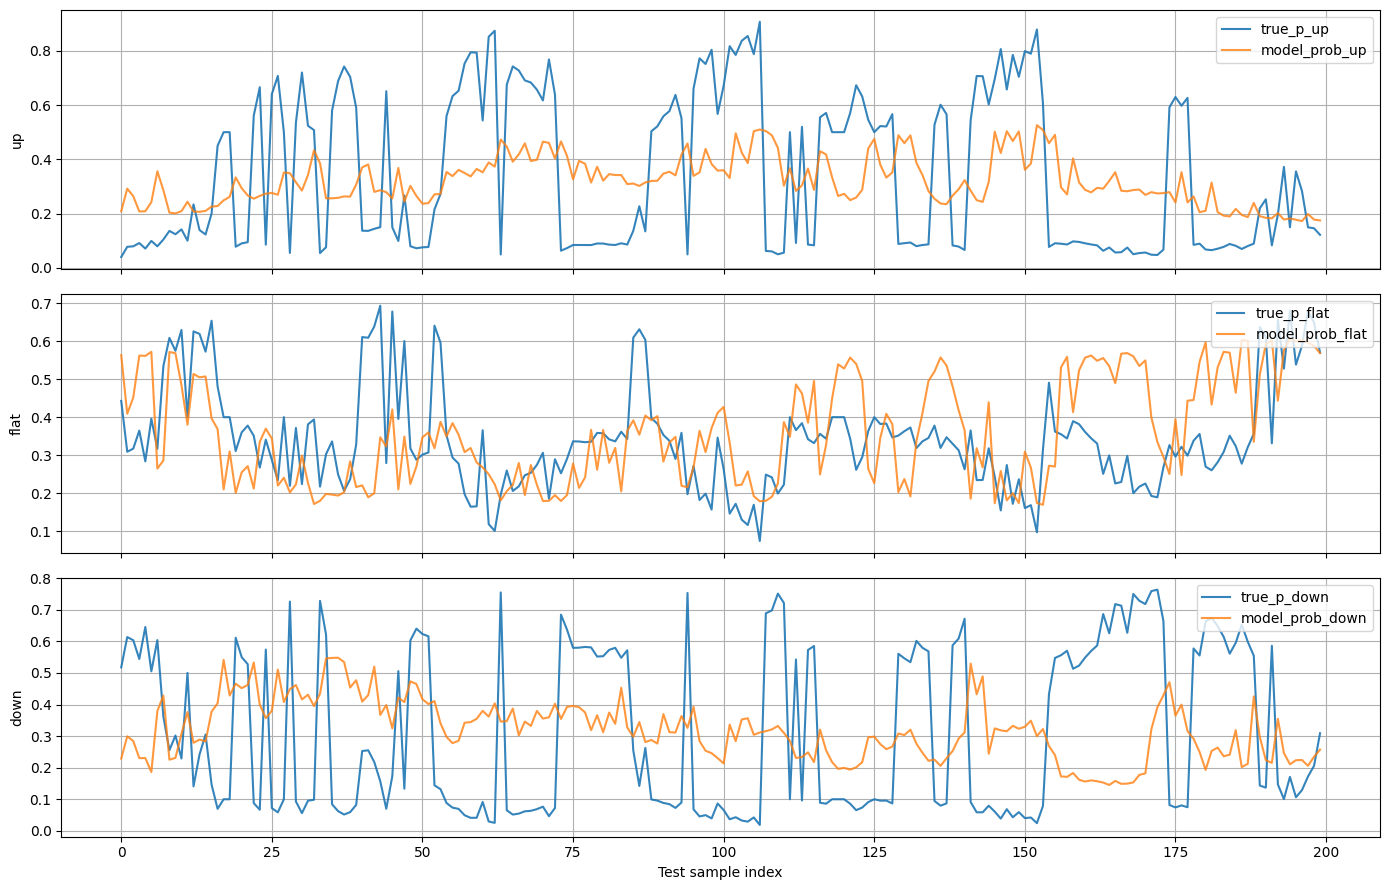

In [48]:
# 9) Plots (no confusion matrix)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curves
axes[0].plot(history['train_loss'], label='train_loss')
axes[0].plot(history['val_loss'], label='val_loss')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# LR curve
axes[1].plot(history['lr'], label='Learning Rate', color='orange')
axes[1].set_title('Learning Rate Schedule')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('LR')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Compare true soft scores vs model probabilities on first N test windows.
plot_n = min(200, len(results))
fig, axes = plt.subplots(len(CLASS_NAMES), 1, figsize=(14, 3 * len(CLASS_NAMES)), sharex=True)
axes = np.atleast_1d(axes)

for ax, class_name in zip(axes, CLASS_NAMES):
    ax.plot(results[f'true_p_{class_name}'].iloc[:plot_n].to_numpy(), label=f'true_p_{class_name}', alpha=0.9)
    ax.plot(results[f'prob_{class_name}'].iloc[:plot_n].to_numpy(), label=f'model_prob_{class_name}', alpha=0.8)
    ax.set_ylabel(class_name)
    ax.grid(True)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Test sample index')
plt.tight_layout()
plt.show()


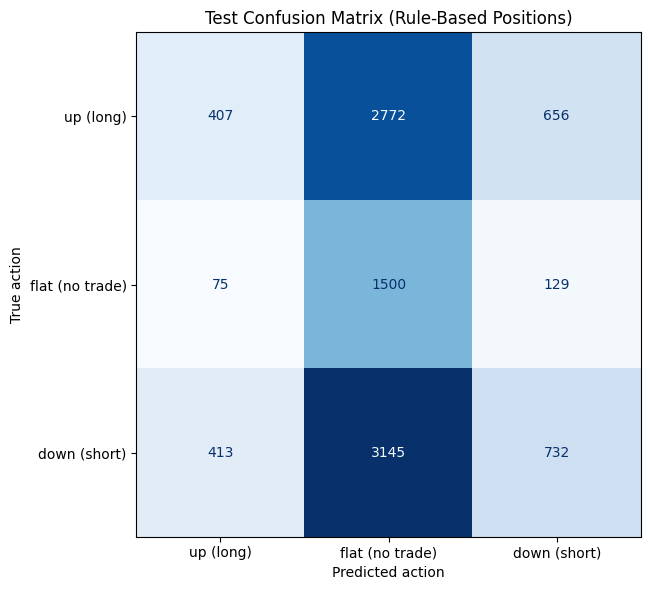

Predicted action distribution:
pred_trade_label
up       895
flat    7417
down    1517
Name: count, dtype: int64

True action distribution:
true_trade_label
up      3835
flat    1704
down    4290
Name: count, dtype: int64



,Date,true_trade_label,prob_up,prob_flat,prob_down,pred_trade_label
0,2025-08-07 21:30:00,down,0.208393,0.562956,0.228651,flat
1,2025-08-07 22:00:00,down,0.291874,0.408893,0.299234,flat
2,2025-08-07 22:30:00,down,0.263914,0.451773,0.284313,flat
3,2025-08-07 23:00:00,down,0.207702,0.561978,0.230320,flat
4,2025-08-07 23:30:00,down,0.208456,0.561144,0.230401,flat
5,2025-08-08 00:00:00,down,0.242061,0.571754,0.186185,flat
6,2025-08-08 00:30:00,down,0.355803,0.264773,0.379424,flat
7,2025-08-08 01:00:00,flat,0.285653,0.286160,0.428188,down
8,2025-08-08 01:30:00,flat,0.203400,0.571301,0.225299,flat
9,2025-08-08 02:00:00,flat,0.200758,0.568294,0.230948,flat


In [49]:
# 10) Test confusion matrix (rule-based trade decisions)
import matplotlib.pyplot as plt

# Mapping: p_buy=up, p_hold=flat, p_sell=down.
results = results.copy()

def derive_trade_labels(p_buy, p_hold, p_sell):
    trade_labels = np.full(len(p_buy), 'flat', dtype=object)
    long_mask = (p_sell < 0.32) & (p_buy > p_hold)
    short_mask = (~long_mask) & (p_buy < 0.32) & (p_sell > p_hold)
    trade_labels[long_mask] = 'up'
    trade_labels[short_mask] = 'down'
    return trade_labels

results['true_trade_label'] = derive_trade_labels(
    p_buy=results['true_p_up'].to_numpy(),
    p_hold=results['true_p_flat'].to_numpy(),
    p_sell=results['true_p_down'].to_numpy(),
)
pred_trade_label = derive_trade_labels(
    p_buy=results['prob_up'].to_numpy(),
    p_hold=results['prob_flat'].to_numpy(),
    p_sell=results['prob_down'].to_numpy(),
)
results['pred_trade_label'] = pred_trade_label

cm = confusion_matrix(results['true_trade_label'], results['pred_trade_label'], labels=CLASS_NAMES)
display_labels = ['up (long)', 'flat (no trade)', 'down (short)']

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title('Test Confusion Matrix (Rule-Based Positions)')
ax.set_xlabel('Predicted action')
ax.set_ylabel('True action')
plt.tight_layout()
plt.show()

print('Predicted action distribution:')
print(results['pred_trade_label'].value_counts().reindex(CLASS_NAMES, fill_value=0))

print()
print('True action distribution:')
print(results['true_trade_label'].value_counts().reindex(CLASS_NAMES, fill_value=0))

print()
results[['Date', 'true_trade_label', 'prob_up', 'prob_flat', 'prob_down', 'pred_trade_label']].head(10)
